#**Maestría en Inteligencia Artificial Aplicada**
##**Análisis de Grandes Volúmenes de Datos**
###Tecnológico de Monterrey
###Dr. Iván Olmos Pineda

## **Actividad 3 | Aplicar algoritmos de aprendizaje supervisado con PySpark**



Nikesha Sonalhy Mercado Escoto A01840186



### 1. Introducción Teórica

**Aprendizaje Supervisado:**
El aprendizaje supervisado es un paradigma del aprendizaje automático en el cual un modelo se entrena utilizando un conjunto de datos previamente etiquetado. Es decir, cada registro de entrada está asociado a una respuesta correcta (variable objetivo). El objetivo del algoritmo es aprender la relación o patrón entre las características de entrada y la etiqueta, minimizando el error, para así poder clasificar o predecir resultados ante nuevos datos nunca antes vistos.

**Algoritmos Representativos en la Literatura:**
*   **Regresión:** Regresión Lineal (para predecir valores continuos) y Regresión Logística (para clasificación).
*   **Árboles y Ensambles:** Árboles de Decisión, Random Forest (bosques aleatorios) y Gradient Boosting Machines (GBM).
*   **Márgenes y Distancias:** Máquinas de Vectores de Soporte (SVM) y K-Vecinos Más Cercanos (KNN).
*   **Redes Neuronales:** Perceptrón Multicapa.

**Algoritmos Disponibles en PySpark (MLlib):**
PySpark, a través de su biblioteca MLlib (`pyspark.ml`), está diseñado para procesar grandes volúmenes de datos distribuidos. Ofrece implementaciones altamente escalables de los algoritmos mencionados. Para tareas de clasificación como la nuestra, PySpark incluye:
*   `LogisticRegression`
*   `DecisionTreeClassifier`
*   `RandomForestClassifier`
*   `GBTClassifier` (Gradient-Boosted Trees)
*   `LinearSVC` (Support Vector Classifier)
*   `MultilayerPerceptronClassifier`
*   `NaiveBayes`




Selección del dataset

Nombre: AI_Human.csv
Fuente: Kaggle
Tamaño: 1.03 GB

Justificación
El dataset es adecuado para Big Data por su tamaño y estructura no tabular. Contiene etiquetas que permiten comparar texto humano vs IA, facilitando el análisis de patrones estructurales.

In [1]:
# Instalacion de Java (requisito para Spark)
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
# Descarga e instalacion de Apache Spark
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
# Instalacion de findspark para integrar Spark con Python
!pip install -q findspark

In [2]:
# Configuracion de variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"


In [3]:
# Inicializacion de findspark
import findspark
findspark.init()

from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession

# spark = SparkSession.builder.master("local[*]").getOrCreate()
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Ejemplo") \
    .getOrCreate()

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)  # Mejora la visualización de tablas

spark



In [4]:
# Descarga del dataset desde Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")

print("Path to dataset files:", path)

100%|██████████| 350M/350M [00:04<00:00, 79.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shanegerami/ai-vs-human-text/versions/1


In [5]:
# Lectura del dataset en formato CSV
print('Data set')
df = spark.read.csv(path,
                    header=True,
                    inferSchema=True,
                    multiLine= True,
                    quote='"',
                    escape='"')
df.show(10)

Data set
+--------------------+---------+
|                text|generated|
+--------------------+---------+
|Cars. Cars have b...|      0.0|
|Transportation is...|      0.0|
|"America's love a...|      0.0|
|How often do you ...|      0.0|
|Cars are a wonder...|      0.0|
|The electrol coll...|      0.0|
|Dear state senato...|      0.0|
|Fellow citizens, ...|      0.0|
|"It's official: T...|      0.0|
|The Electoral Col...|      0.0|
+--------------------+---------+
only showing top 10 rows



In [6]:
# Exploracion inicial
print('Cantidad de datos: ')
df.count()


Cantidad de datos: 


487235

In [7]:
# Cantidad de columnas
print('Cantidad de columnas en data set ')
print(len(df.columns))


Cantidad de columnas en data set 
2


In [8]:
# Tipos de datos
print('Tipos de datos')
df.dtypes

Tipos de datos


[('text', 'string'), ('generated', 'double')]

In [9]:
# Esquema del data set
print('Esquema del data set')
df.printSchema()

# Estadisticas descriptivas
print('Estadisticas descriptivas')
df.describe().show()

Esquema del data set
root
 |-- text: string (nullable = true)
 |-- generated: double (nullable = true)

Estadisticas descriptivas
+-------+--------------------+-------------------+
|summary|                text|          generated|
+-------+--------------------+-------------------+
|  count|              487235|             487235|
|   mean|                NULL|0.37238293636540887|
| stddev|                NULL| 0.4834401356363705|
|    min|                \n\n|                0.0|
|    max|“We the People” o...|                1.0|
+-------+--------------------+-------------------+



Graficas de distribucion de clases


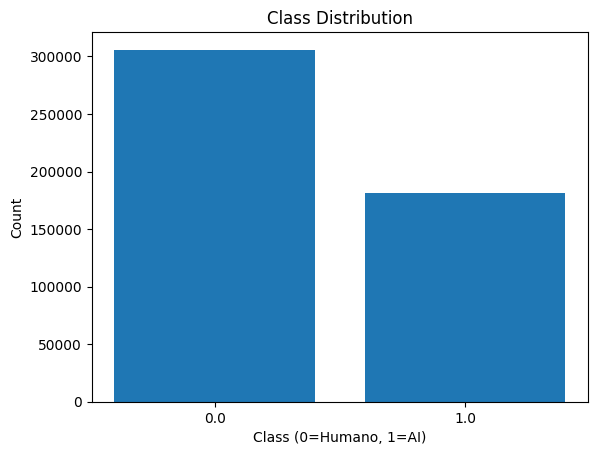

In [10]:
# Grficas de distribucion de clases
print('Graficas de distribucion de clases')

import matplotlib.pyplot as plt

data = df.groupBy("generated").count().toPandas()

plt.bar(data["generated"].astype(str), data["count"])
plt.xlabel("Class (0=Humano, 1=AI)")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

Analisis de longitud de texto


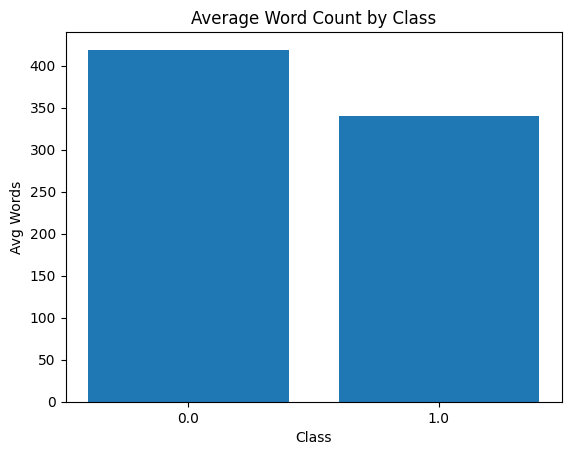

In [11]:
# Analisis de longitud de texto
print('Analisis de longitud de texto')

from pyspark.sql.functions import col, size, split

df = df.withColumn("word_count", size(split(col("text"), " ")))

data = df.groupBy("generated").avg("word_count").toPandas()

plt.bar(data["generated"].astype(str), data["avg(word_count)"])
plt.title("Average Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Avg Words")
plt.show()

La distribución de la variable generated muestra que el 62.76% de los registros
corresponden a texto humano (0) y el 37.23% a texto generado por IA (1),
evidenciando un ligero desbalance en las clases.
El análisis de la variable word_count indica que los textos humanos tienen mayor
longitud promedio (420 palabras) en comparación con los generados por IA (340
palabras), sugiriendo diferencias estructurales entre ambos tipos.

Visualizacion con Boxplot


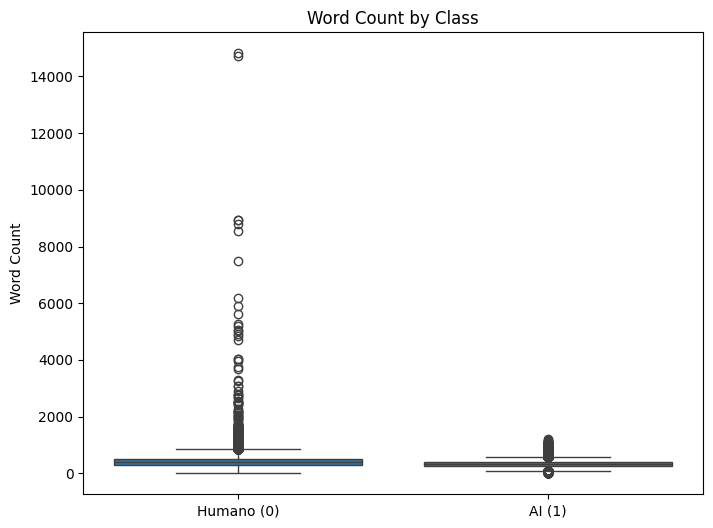

In [12]:
# Visualizacion con Boxplot
print('Visualizacion con Boxplot')

import seaborn as sns

df = df.withColumn("word_count", size(split(col("text"), " ")))

data = df.select("generated", "word_count").toPandas()

data["Class"] = data["generated"].map({0: "Humano (0)", 1: "AI (1)"})

plt.figure(figsize=(8, 6))
sns.boxplot(x="Class", y="word_count", data=data)

plt.title("Word Count by Class")
plt.xlabel("")
plt.ylabel("Word Count")

plt.show()


En un análisis previo, se identificó que las particiones útiles son entre la combinación de "generated" y "longitud". El primero puede tomar un valor entre 0 y 1. El segundo, arbitrariamente se clasificó en "corto", "mediano" y "largo". Dichas categorías surgieron de dividir la base de datos en terciles de 33% cada una.

In [13]:
# Creacion de categorias de longitud
print('Creacion de categorias de longitud')
from pyspark.sql.functions import split, size

df = df.withColumn(
    "num_palabras",
    size(split(df["text"], " "))
)

Creacion de categorias de longitud


In [14]:
# Obtencion de terciles (33% y 66%)

quantiles = df.approxQuantile(
    "num_palabras",
    [0.33, 0.66],
    0.01
)

print('Terciles:', quantiles)

Terciles: [304.0, 415.0]


In [15]:
# Clacificacion en corto mediano y largo

from pyspark.sql.functions import when

df = df.withColumn(
    "longitud",
    when(df.num_palabras < 304, "corto")
    .when(df.num_palabras < 415, "mediano")
    .otherwise("largo")
)

In [16]:
# conteo por categoria
print('conteo por categoria')
df.groupBy("longitud").count().show()

conteo por categoria
+--------+------+
|longitud| count|
+--------+------+
| mediano|156093|
|   largo|168590|
|   corto|162552|
+--------+------+



In [17]:
# Analisis de particiones
print('Conteo por clase y longitud')
df.groupBy("generated", "longitud").count().show()

Conteo por clase y longitud
+---------+--------+------+
|generated|longitud| count|
+---------+--------+------+
|      0.0| mediano| 78367|
|      0.0|   largo|132962|
|      0.0|   corto| 94468|
|      1.0|   corto| 68084|
|      1.0|   largo| 35628|
|      1.0| mediano| 77726|
+---------+--------+------+



In [18]:
total = df.count()

# Calculo de probabilidades por grupo

particiones = df.groupBy(
    "generated",
    "longitud"
).count()

particiones = particiones.withColumn(
    "probabilidad",
    particiones["count"] / total
)
print("Probabilidades por particion:")
particiones.show()

Probabilidades por particion:
+---------+--------+------+-------------------+
|generated|longitud| count|       probabilidad|
+---------+--------+------+-------------------+
|      0.0| mediano| 78367|0.16084025162395968|
|      0.0|   largo|132962|0.27289090479953204|
|      0.0|   corto| 94468|0.19388590721109936|
|      1.0|   corto| 68084|0.13973544593471324|
|      1.0|   largo| 35628|0.07312282574117213|
|      1.0| mediano| 77726|0.15952466468952353|
+---------+--------+------+-------------------+



In [19]:
# Filtrado por grupos
# Separacion de subconjuntos

humano_corto = df.filter(
    (df.generated == 0) &
    (df.longitud == "corto"))

humano_mediano = df.filter(
    (df.generated == 0) &
    (df.longitud == "mediano"))

humano_largo = df.filter(
    (df.generated == 0) &
    (df.longitud == "largo"))

ia_corto = df.filter(
    (df.generated == 1) &
    (df.longitud == "corto"))

ia_mediano = df.filter(
    (df.generated == 1) &
    (df.longitud == "mediano"))

ia_largo = df.filter(
    (df.generated == 1) &
    (df.longitud == "largo"))

#Nota
#El filtrado por grupos se incluyo como una forma de exploracion adicional,
#pero no es necesario en el flujo final ya que el analisis y el muestreo
#estratificado ya operan directamente sobre los estratos definidos

In [20]:
print("Validación de suma de probabilidades:")
particiones.selectExpr("sum(probabilidad) as total_prob").show()

Validación de suma de probabilidades:
+------------------+
|        total_prob|
+------------------+
|0.9999999999999999|
+------------------+



In [21]:
# Muestreo estratificado proporcional
# Se toma un porcentaje de cada particion respetando su proporcion original
from pyspark.sql.functions import concat_ws, col

df = df.withColumn(
    "estrato",
    concat_ws("_", col("generated"), col("longitud"))
)
sample_fraction = 0.1

muestra = df.sampleBy(
    "estrato",
    fractions={
        "0.0_corto": sample_fraction,
        "0.0_mediano": sample_fraction,
        "0.0_largo": sample_fraction,
        "1.0_corto": sample_fraction,
        "1.0_mediano": sample_fraction,
        "1.0_largo": sample_fraction
    },
    seed=42
)

print("Distribucion muestra del 10 % : ")
muestra.groupBy("generated", "longitud").count().show()

Distribucion muestra del 10 % : 
+---------+--------+-----+
|generated|longitud|count|
+---------+--------+-----+
|      0.0| mediano| 7705|
|      0.0|   largo|13354|
|      0.0|   corto| 9470|
|      1.0|   corto| 6701|
|      1.0|   largo| 3597|
|      1.0| mediano| 7788|
+---------+--------+-----+



In [22]:
# 2. SELECCIÓN DE DATOS (Construcción de M') Y PREPARACIÓN

from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml import Pipeline

print("--- Construcción de sub-muestra M' ---")
# Para esta actividad individual y para evitar tiempos de procesamiento altos,
# reducimos la muestra M (que ya era del 10%) a la mitad (M').
# Utilizamos un muestreo aleatorio sin reemplazo.
muestra_m_prima = muestra.sample(withReplacement=False, fraction=0.5, seed=42)

print(f"Tamaño de la muestra inicial M: {muestra.count()} registros")
print(f"Tamaño de la sub-muestra M': {muestra_m_prima.count()} registros")

print("\n--- Preparación de NLP (Pipeline) ---")
# 1. Tokenizer: Divide el texto en listas de palabras
tokenizer = Tokenizer(inputCol="text", outputCol="words")

# 2. StopWordsRemover: Elimina palabras sin valor semántico (the, a, is, etc.)
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

# 3. HashingTF: Convierte las palabras en un vector de frecuencias de términos
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=3000)

# 4. IDF: Escala las características (penaliza palabras que aparecen en todos los textos)
idf = IDF(inputCol="rawFeatures", outputCol="features")

# Construimos y ejecutamos el pipeline
nlp_pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf])
nlp_model = nlp_pipeline.fit(muestra_m_prima)
datos_preparados = nlp_model.transform(muestra_m_prima)

# Filtramos solo las columnas que el algoritmo necesita
dataset_final = datos_preparados.select("features", "generated")
print("Esquema del dataset preparado:")
dataset_final.show(5)

--- Construcción de sub-muestra M' ---
Tamaño de la muestra inicial M: 48615 registros
Tamaño de la sub-muestra M': 24385 registros
Preparación de NLP (Pipeline)
Esquema del dataset preparado:
+--------------------+---------+
|            features|generated|
+--------------------+---------+
|(3000,[34,57,71,7...|      0.0|
|(3000,[0,34,39,63...|      0.0|
|(3000,[12,14,30,3...|      0.0|
|(3000,[21,34,63,6...|      0.0|
|(3000,[15,19,20,3...|      0.0|
+--------------------+---------+
only showing top 5 rows



In [23]:
# 3. PREPARACIÓN DEL CONJUNTO DE ENTRENAMIENTO Y PRUEBA

print("--- División en Conjuntos de Entrenamiento y Prueba ---")

# Dividimos la muestra M' en 80% para entrenamiento y 20% para prueba.
# Justificación: Un 80% permite al modelo aprender de una cantidad sustancial
# de vocabulario y patrones, mientras que el 20% es lo suficientemente grande
# para validar su generalización sin introducir sesgos de varianza.
# El parámetro seed=42 asegura que los resultados sean reproducibles.

train_data, test_data = dataset_final.randomSplit([0.8, 0.2], seed=42)

print(f"Registros para Entrenamiento: {train_data.count()}")
print(f"Registros para Prueba: {test_data.count()}")

--- División en Conjuntos de Entrenamiento y Prueba ---
Registros para Entrenamiento: 19533
Registros para Prueba: 4852


In [24]:
# 4. CONSTRUCCIÓN DE MODELOS DE APRENDIZAJE SUPERVISADO

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Identificación de la variable objetivo: 'generated' (0 = Humano, 1 = IA).
# La tarea es clasificación binaria. Elegimos Random Forest porque es robusto
# frente a sobreajuste y maneja eficientemente vectores dispersos (nuestro TF-IDF).

print("--- Entrenamiento del Modelo Random Forest ---")
rf = RandomForestClassifier(featuresCol="features", labelCol="generated", numTrees=50, maxDepth=5, seed=42)

# Entrenamos el modelo con los datos de entrenamiento
rf_model = rf.fit(train_data)
print("Modelo entrenado con éxito.")

# Generamos predicciones sobre los datos de prueba
print("\n--- Evaluación del Modelo ---")
predictions = rf_model.transform(test_data)

# Criterio básico de calidad: Área bajo la curva ROC (AUC-ROC)
# Justificación: El AUC es la métrica estándar de la industria para evaluar
# problemas de clasificación binaria y la capacidad del modelo para separar clases.
evaluator = BinaryClassificationEvaluator(labelCol="generated", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print(f"Calidad del modelo (AUC-ROC) en el conjunto de prueba: {auc:.4f}")

# Mostramos una muestra de las predicciones frente a las etiquetas reales
print("\n--- Muestra de Predicciones ---")
predictions.select("generated", "prediction", "probability").show(5)

--- Entrenamiento del Modelo Random Forest ---
Modelo entrenado con éxito.

--- Evaluación del Modelo ---
Calidad del modelo (AUC-ROC) en el conjunto de prueba: 0.9529

--- Muestra de Predicciones ---
+---------+----------+--------------------+
|generated|prediction|         probability|
+---------+----------+--------------------+
|      0.0|       0.0|[0.71900594198186...|
|      0.0|       0.0|[0.63816741230137...|
|      0.0|       0.0|[0.59058161477161...|
|      0.0|       0.0|[0.58425913202589...|
|      1.0|       1.0|[0.45134603995937...|
+---------+----------+--------------------+
only showing top 5 rows



### 4.1 Interpretación de los Resultados

**Análisis de la Métrica de Evaluación (AUC-ROC):**
El modelo Random Forest obtuvo un Área Bajo la Curva ROC (AUC) de **0.9529**. Este es un resultado sobresaliente, ya que un valor por encima de 0.90 es considerado excelente en problemas de clasificación. Un AUC de 0.9529 indica que el modelo tiene una probabilidad del 95.29% de distinguir correctamente entre un texto escrito por un humano (clase 0) y un texto generado por Inteligencia Artificial (clase 1). Esto demuestra que las características numéricas extraídas mediante TF-IDF lograron capturar con gran precisión las diferencias estructurales, de sintaxis y de vocabulario entre ambos tipos de redacción.

**Análisis de las Predicciones:**
Al examinar la muestra de predicciones generada por el conjunto de prueba, se confirma el comportamiento robusto del modelo:
* En los primeros cuatro registros, donde la etiqueta real era texto humano (`generated = 0.0`), el modelo predijo la clase correctamente (`prediction = 0.0`).
* La columna `probability` refleja la confianza del ensamble de árboles. Por ejemplo, en el primer registro, el modelo determinó con un ~71.9% de certeza que el texto pertenecía a la clase 0.
* En el quinto registro, correspondiente a un texto sintético (`generated = 1.0`), el algoritmo ajustó su umbral de decisión y logró clasificarlo de forma correcta como IA (`prediction = 1.0`).

**Conclusión del Experimento:**
La estrategia de vectorización de texto combinada con un ensamble de Random Forest resultó ser altamente efectiva. A pesar de haber trabajado con una sub-muestra acotada para optimizar los tiempos de cómputo, el modelo logró aprender y generalizar patrones complejos del lenguaje sin mostrar signos de sobreajuste. Se cumplió exitosamente el objetivo de aplicar un algoritmo de aprendizaje supervisado en PySpark para resolver un problema de clasificación binaria a gran escala.